# **Assignment 1**
**Course:** Introduction to Data Security Practicum (ELTE)  
**Total Points:** 20  
**Time:** 45 min

---

1. **Part 1 (7 pts):** Evasion Attacks – Bypass a spam filter via word substitution
2. **Part 2 (5 pts):** Data Poisoning – Corrupt training data to degrade a model
3. **Part 3 (4 pts):** Model Trojans – Inject hidden functionality into model weights
4. **Part 4 (4 pts):** Integration & Defense – Design a defense strategy

Each part includes scaffolded code with `TODO` comments. Follow the instructions and fill in the blanks.

## **PART 1: Evasion Attacks (7 pts)**

Implement a **white-box greedy substitution** attack against a TF-IDF + Logistic Regression spam classifier. Replace "spammy" words with "hammy" words until the filter is fooled.

- Extract model weights and identify important features
- Implement iterative gradient-free attacks
- Measure attack success (ASR, L0)

In [1]:
import pandas as pd
import numpy as np
import joblib
import re

# Load the provided pre-trained model and vectorizer
model = joblib.load('spam_classifier.joblib')
vectorizer = joblib.load('tfidf_vectorizer.joblib')

# --- HELPER FUNCTIONS PROVIDED ---
def get_prediction(text):
    """Returns (predicted_class, probabilities). Class 1 = Spam, Class 0 = Ham."""
    features = vectorizer.transform([text])
    prediction = model.predict(features)[0]
    probs = model.predict_proba(features)[0]
    return prediction, probs

def get_word_score(word):
    """Returns the model weight for a word. Positive = Spammy, Negative = Hammy."""
    word = word.lower()
    vocab = vectorizer.vocabulary_
    weights = model.coef_[0]
    if word in vocab:
        return weights[vocab[word]]
    return 0.0

def get_all_vocab_words():
    """Returns all words in the model vocabulary."""
    return vectorizer.get_feature_names_out()

C:\Users\arunp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\arunp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\arunp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle e

In [2]:
# Test if model and vectorizer loaded correctly
print("✓ Model loaded successfully!" if model else "✗ Model failed")
print("✓ Vectorizer loaded successfully!" if vectorizer else "✗ Vectorizer failed")

# Test prediction on a simple text
test_text = "Congratulations! You won a free prize!"
features = vectorizer.transform([test_text])
prediction = model.predict(features)[0]

print(f"\nTest text: '{test_text}'")
print(f"Prediction: {prediction} (1 = Spam, 0 = Ham)")

if prediction == 1:
    print("✓ Model thinks this is SPAM - working correctly!")
else:
    print("✓ Model thinks this is HAM - working correctly!")

✓ Model loaded successfully!
✓ Vectorizer loaded successfully!

Test text: 'Congratulations! You won a free prize!'
Prediction: 1 (1 = Spam, 0 = Ham)
✓ Model thinks this is SPAM - working correctly!


### Task 1.1: Build Ham Library (2 pts)
Create a list of the top 20 words with the **most negative weights** (strongest indicators of "Ham").

In [3]:
# TODO: Find the top 20 words with the most negative weights.
# Hint: Use get_all_vocab_words() and model.coef_[0], then sort by ascending weight.

ham_library = []  # FILL THIS IN

print(f"Ham library (first 5): {ham_library[:5]}")

Ham library (first 5): []


In [4]:
# Let's understand the model structure

# Get all words in vocabulary
all_words = get_all_vocab_words()
print(f"Total number of words the model knows: {len(all_words)}")
print(f"First 10 words: {list(all_words)[:10]}")

# Look at the weights (spam scores)
weights = model.coef_[0]
print(f"\nShape of weights array: {weights.shape}")

# Find the most spammy and most hammy words
word_list = []
for word in all_words[:100]:  # Check first 100 words
    idx = vectorizer.vocabulary_[word]
    weight = weights[idx]
    word_list.append((word, weight))

# Sort to see top spam and top ham
word_list.sort(key=lambda x: x[1])

print(f"\nTop 5 HAM words (most negative):")
for word, weight in word_list[:5]:
    print(f"  '{word}': {weight:.4f}")

print(f"\nTop 5 SPAM words (most positive):")
for word, weight in word_list[-5:]:
    print(f"  '{word}': {weight:.4f}")

Total number of words the model knows: 5000
First 10 words: ['00', '000', '008704050406', '0089', '0121', '01223585236', '01223585334', '0125698789', '02', '0207']

Shape of weights array: (5000,)

Top 5 HAM words (most negative):
  '0125698789': 0.0000
  '0776xxxxxxx': 0.0000
  '08': 0.0000
  '08000776320': 0.0000
  '09050003091': 0.0424

Top 5 SPAM words (most positive):
  '04': 0.7046
  '00': 0.7296
  '08000839402': 0.8121
  '000': 1.1189
  '0800': 1.2082


In [5]:
# Create list of all words with their weights
all_words = get_all_vocab_words()
weights = model.coef_[0]

# Create pairs of (word, weight)
word_weight_pairs = []
for word in all_words:
    idx = vectorizer.vocabulary_[word]
    weight = weights[idx]
    word_weight_pairs.append((word, weight))

# Sort by weight (smallest first = most negative = best ham words)
word_weight_pairs.sort(key=lambda x: x[1])

# Take the top 20 most negative words
ham_library = [word for word, weight in word_weight_pairs[:20]]

# Print the results
print("Top 20 Ham Words (most negative weights):")
print("-" * 40)
for i, (word, weight) in enumerate(word_weight_pairs[:20]):
    print(f"{i+1:2d}. '{word}': {weight:.4f}")

print(f"\nham_library list: {ham_library}")

Top 20 Ham Words (most negative weights):
----------------------------------------
 1. 'ok': -1.8075
 2. 'gt': -1.6912
 3. 'lt': -1.6773
 4. 'll': -1.6637
 5. 'da': -1.4181
 6. 'come': -1.3884
 7. 'home': -1.3454
 8. 'got': -1.3289
 9. 'lor': -1.2181
10. 'sorry': -1.1816
11. 'hey': -1.1410
12. 'going': -1.1174
13. 'later': -1.1157
14. 'good': -1.0807
15. 'way': -1.0178
16. 'sir': -0.9605
17. 'did': -0.9333
18. 'yeah': -0.9196
19. 'happy': -0.9173
20. 'right': -0.9068

ham_library list: ['ok', 'gt', 'lt', 'll', 'da', 'come', 'home', 'got', 'lor', 'sorry', 'hey', 'going', 'later', 'good', 'way', 'sir', 'did', 'yeah', 'happy', 'right']


In [6]:
# Test the ham_library with a sample text
test_email = "URGENT! You have won a 1 week FREE membership!"

print("Original email:", test_email)

# Check if any ham words are already in the email
found_ham = []
for word in ham_library:
    if word in test_email.lower():
        found_ham.append(word)

if found_ham:
    print(f"\nHam words already in email: {found_ham}")
else:
    print("\nNo ham words found in this email - that's why it's spam!")

# Test the score of a spam word vs ham word
print(f"\nScore of 'urgent' (spammy): {get_word_score('urgent'):.4f}")
print(f"Score of '{ham_library[0]}' (hammy): {get_word_score(ham_library[0]):.4f}")

Original email: URGENT! You have won a 1 week FREE membership!

No ham words found in this email - that's why it's spam!

Score of 'urgent' (spammy): 2.4421
Score of 'ok' (hammy): -1.8075


### Task 1.2: Find Most Spammy Word (1 pts)
Write a function that identifies the word in a given text with the **highest positive weight**.

In [7]:
def find_most_spammy_word(text):
    # TODO: Implement this function.
    # 1. Tokenize the text using: re.findall(r'\\b\\w+\\b', text)
    # 2. For each word, get its score using get_word_score(word)
    # 3. Return the word with the HIGHEST score (most spammy)
    # Hint: If no words are found or all have score 0, return None
    
    best_word = None
    # YOUR CODE HERE
    
    return best_word

# Test it
test_email = "URGENT! YOU HAVE WON A FREE PRIZE"
result = find_most_spammy_word(test_email)
print(f"Most spammy word in test email: '{result}'")

Most spammy word in test email: 'None'


In [8]:
import re

def find_most_spammy_word(text):
    """
    Find the word with the highest spam score in the text.
    Returns the word (string) or None if no words found.
    """
    # Step 1: Convert to lowercase and extract all words
    # \b\w+\b finds whole words (letters and numbers only)
    words = re.findall(r'\b\w+\b', text.lower())
    
    print(f"Words found: {words}")  # This helps you see what's happening
    
    # Step 2: Initialize variables to track the best word
    best_word = None
    best_score = -float('inf')  # Start with a very low number
    
    # Step 3: Check each word's spam score
    for word in words:
        score = get_word_score(word)
        print(f"  '{word}': score = {score:.4f}")
        
        # If this word has a higher score, make it the new best
        if score > best_score:
            best_score = score
            best_word = word
    
    print(f"\nMost spammy word: '{best_word}' with score {best_score:.4f}")
    return best_word

# Test with the example
test_email = "URGENT! YOU HAVE WON A FREE PRIZE"
result = find_most_spammy_word(test_email)
print(f"\nFinal result: '{result}'")

Words found: ['urgent', 'you', 'have', 'won', 'a', 'free', 'prize']
  'urgent': score = 2.4421
  'you': score = 0.0000
  'have': score = 0.0000
  'won': score = 2.3738
  'a': score = 0.0000
  'free': score = 2.9667
  'prize': score = 2.5274

Most spammy word: 'free' with score 2.9667

Final result: 'free'


### Task 1.3: Iterative Evasion Attack (2 pts)
Implement the attack loop: repeatedly replace the most spammy word with a ham word until the model flips to Ham.

In [9]:
target_spam_email = "URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net"

In [10]:
def guided_evasion_attack(email, ham_library):
    """Iteratively replace spammy words with ham words until model predicts Ham.
    
    Args:
        email (str): Original spam email
        ham_library (list): List of ham words to substitute
    
    Returns:
        (adversarial_email, num_changes): Modified email and substitution count
    """
    current_email = email
    changes = 0
    
    # TODO: Implement the loop. Requirements:
    # 1. Loop while prediction is Spam (pred == 1)
    # 2. Find the most spammy word using find_most_spammy_word()
    # 3. If no word found, break
    # 4. Pick a replacement from ham_library[changes % len(ham_library)]
    # 5. Replace the word using: re.sub(r'\\b' + re.escape(word) + r'\\b', replacement, current_email, count=1, flags=re.IGNORECASE)
    # 6. Increment changes
    # 7. Add safety cap: break if changes >= 20
    
    # YOUR CODE HERE
    
    return current_email, changes

# Run the attack
adv_email, n_changes = guided_evasion_attack(target_spam_email, ham_library)
pred, probs = get_prediction(adv_email)

print(f"Original prediction: Spam (1.0)")
print(f"Attack result: {'SUCCESS' if pred == 0 else 'FAILED'}")
print(f"Changes made: {n_changes}")
print(f"Final Ham probability: {probs[0]*100:.2f}%")
print(f"\nAdversarial email: {adv_email}")

Original prediction: Spam (1.0)
Attack result: FAILED
Changes made: 0
Final Ham probability: 5.27%

Adversarial email: URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net


In [11]:
# The target spam email we want to trick the filter
target_spam_email = "URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net"

# Check what the model thinks of this email
pred, probs = get_prediction(target_spam_email)
print("=" * 60)
print("ORIGINAL EMAIL ANALYSIS")
print("=" * 60)
print(f"Email: {target_spam_email}")
print(f"\nPrediction: {'SPAM' if pred == 1 else 'HAM'}")
print(f"Spam probability: {probs[1]*100:.2f}%")
print(f"Ham probability: {probs[0]*100:.2f}%")

ORIGINAL EMAIL ANALYSIS
Email: URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net

Prediction: SPAM
Spam probability: 94.73%
Ham probability: 5.27%


In [12]:
def guided_evasion_attack(email, ham_library):
    """
    Iteratively replace spammy words with ham words until the model says HAM.
    
    Args:
        email: The spam email to attack
        ham_library: List of ham words to use as replacements
    
    Returns:
        (modified_email, number_of_changes)
    """
    current_email = email
    changes = 0
    max_changes = 20  # Safety limit
    
    print("Starting attack...")
    print("-" * 50)
    
    while changes < max_changes:
        # Check current prediction
        pred, probs = get_prediction(current_email)
        
        print(f"\nIteration {changes + 1}:")
        print(f"  Current prediction: {'SPAM' if pred == 1 else 'HAM'} (Spam prob: {probs[1]*100:.1f}%)")
        
        # If it's already HAM, we're done!
        if pred == 0:
            print(f"  ✓ SUCCESS! Email is now classified as HAM!")
            break
        
        # Find the most spammy word in the current email
        spammy_word = find_most_spammy_word(current_email)
        
        if spammy_word is None:
            print("  ✗ No spammy words found - can't continue")
            break
        
        print(f"  Most spammy word: '{spammy_word}'")
        
        # Pick a replacement from ham_library (cycle through the list)
        replacement = ham_library[changes % len(ham_library)]
        print(f"  Replacing with: '{replacement}'")
        
        # Replace the word (case-insensitive, only first occurrence)
        # The regex \b ensures we match whole words only
        current_email = re.sub(
            r'\b' + re.escape(spammy_word) + r'\b',
            replacement,
            current_email,
            count=1,
            flags=re.IGNORECASE
        )
        
        changes += 1
        print(f"  Changes made so far: {changes}")
    
    print("\n" + "=" * 50)
    print(f"Attack finished after {changes} changes")
    
    return current_email, changes

# Now run the attack on our target email
adv_email, n_changes = guided_evasion_attack(target_spam_email, ham_library)

# Show the final result
print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

pred, probs = get_prediction(adv_email)

print(f"Original email: {target_spam_email[:100]}...")
print(f"\nModified email: {adv_email}")
print(f"\nFinal prediction: {'SPAM' if pred == 1 else 'HAM'}")
print(f"Spam probability: {probs[1]*100:.2f}%")
print(f"Ham probability: {probs[0]*100:.2f}%")
print(f"\nAttack {'SUCCESSFUL! ✓' if pred == 0 else 'FAILED! ✗'}")
print(f"Total word substitutions: {n_changes}")

Starting attack...
--------------------------------------------------

Iteration 1:
  Current prediction: SPAM (Spam prob: 94.7%)
Words found: ['urgent', 'you', 'have', 'won', 'a', '1', 'week', 'free', 'membership', 'in', 'our', '100', '000', 'prize', 'jackpot', 'txt', 'the', 'word', 'claim', 'to', 'no', '81010', 't', 'c', 'www', 'dbuk', 'net']
  'urgent': score = 2.4421
  'you': score = 0.0000
  'have': score = 0.0000
  'won': score = 2.3738
  'a': score = 0.0000
  '1': score = 0.0000
  'week': score = 0.9165
  'free': score = 2.9667
  'membership': score = -0.0363
  'in': score = 0.0000
  'our': score = 0.0000
  '100': score = 1.5739
  '000': score = 1.1189
  'prize': score = 2.5274
  'jackpot': score = 0.0239
  'txt': score = 4.5062
  'the': score = 0.0000
  'word': score = 0.6309
  'claim': score = 3.5195
  'to': score = 0.0000
  'no': score = 0.0000
  '81010': score = 0.0239
  't': score = 0.0000
  'c': score = 0.0000
  'www': score = 3.3777
  'dbuk': score = 0.0239
  'net': score

In [14]:
# Function to track probability changes
def track_attack_progress(email, ham_library, max_changes=10):
    """Track how spam probability changes with each replacement"""
    
    probabilities = []
    current_email = email
    
    # Get initial probability
    _, probs = get_prediction(current_email)
    probabilities.append(probs[1])  # Spam probability
    
    print("Tracking spam probability...")
    print("-" * 40)
    
    for i in range(max_changes):
        # Find spammy word
        spammy_word = find_most_spammy_word(current_email)
        if spammy_word is None:
            break
        
        # Replace it
        replacement = ham_library[i % len(ham_library)]
        current_email = re.sub(
            r'\b' + re.escape(spammy_word) + r'\b',
            replacement,
            current_email,
            count=1,
            flags=re.IGNORECASE
        )
        
        # Get new probability
        _, probs = get_prediction(current_email)
        probabilities.append(probs[1])
        
        print(f"After {i+1} changes: Spam probability = {probs[1]*100:.1f}%")
        
        # Stop if we've reached HAM
        if probs[1] < 0.5:
            print(f"\n✓ Reached HAM classification at {i+1} changes!")
            break
    
    return probabilities

# Track the progress
probabilities = track_attack_progress(target_spam_email, ham_library, max_changes=15)

# Create a simple text-based graph
print("\n" + "=" * 60)
print("SPAM PROBABILITY PROGRESSION")
print("=" * 60)

for i, prob in enumerate(probabilities):
    bar_length = int(prob * 40)
    bar = "█" * bar_length + "░" * (40 - bar_length)
    indicator = "✓ HAM" if prob < 0.5 else "  "
    print(f"Step {i:2d}: {bar} {prob*100:5.1f}% {indicator}")

Tracking spam probability...
----------------------------------------
Words found: ['urgent', 'you', 'have', 'won', 'a', '1', 'week', 'free', 'membership', 'in', 'our', '100', '000', 'prize', 'jackpot', 'txt', 'the', 'word', 'claim', 'to', 'no', '81010', 't', 'c', 'www', 'dbuk', 'net']
  'urgent': score = 2.4421
  'you': score = 0.0000
  'have': score = 0.0000
  'won': score = 2.3738
  'a': score = 0.0000
  '1': score = 0.0000
  'week': score = 0.9165
  'free': score = 2.9667
  'membership': score = -0.0363
  'in': score = 0.0000
  'our': score = 0.0000
  '100': score = 1.5739
  '000': score = 1.1189
  'prize': score = 2.5274
  'jackpot': score = 0.0239
  'txt': score = 4.5062
  'the': score = 0.0000
  'word': score = 0.6309
  'claim': score = 3.5195
  'to': score = 0.0000
  'no': score = 0.0000
  '81010': score = 0.0239
  't': score = 0.0000
  'c': score = 0.0000
  'www': score = 3.3777
  'dbuk': score = 0.0239
  'net': score = 0.6432

Most spammy word: 'txt' with score 4.5062
After 1

### Task 1.4: Evaluation Metrics (2 pts)
Compute **Attack Success Rate (ASR)** and **Average Perturbation (L0)** over 50 spam samples.

In [15]:
df = pd.read_csv('spam_dataset.csv')
spam_samples = df[df['label'] == 1].head(50)['text'].tolist()

success_count = 0
l0_successful = []

# TODO: Loop through spam_samples, run attack on each, and collect metrics.
# - Count successful attacks (pred == 0)
# - Record number of changes for successful attacks in l0_successful list

# YOUR CODE HERE

asr = (success_count / len(spam_samples)) * 100
avg_l0 = np.mean(l0_successful) if l0_successful else 0.0

print(f"Attack Success Rate (ASR): {asr:.1f}%")
print(f"Average Perturbation (L0): {avg_l0:.2f} word substitutions")
print(f"Successful attacks: {success_count}/{len(spam_samples)}")

Attack Success Rate (ASR): 0.0%
Average Perturbation (L0): 0.00 word substitutions
Successful attacks: 0/50


In [17]:
import pandas as pd
import numpy as np

print("=" * 60)
print("TASK 1.4: EVALUATING ATTACK SUCCESS")
print("=" * 60)

# Load the dataset
df = pd.read_csv('spam_dataset.csv')
print(f"Dataset loaded: {len(df)} total emails")
print(f"Spam emails: {len(df[df['label'] == 1])}")
print(f"Ham emails: {len(df[df['label'] == 0])}")

# Take first 50 spam emails for testing
spam_samples = df[df['label'] == 1].head(50)['text'].tolist()
print(f"\nTesting on {len(spam_samples)} spam emails...")

# Initialize counters
success_count = 0
l0_successful = []  # Track changes for successful attacks

print("\n" + "-" * 50)
print("Running attacks (this may take a moment)...")
print("-" * 50)

# Loop through each spam email (without progress bar)
for i, email in enumerate(spam_samples):
    # Print progress every 10 emails
    if (i + 1) % 10 == 0:
        print(f"  Processed {i + 1}/{len(spam_samples)} emails...")
    
    # Try to attack this email
    adv_email, changes = guided_evasion_attack(email, ham_library)
    pred, _ = get_prediction(adv_email)
    
    # Check if attack was successful (predicted as HAM = 0)
    if pred == 0:
        success_count += 1
        l0_successful.append(changes)

# Calculate metrics
asr = (success_count / len(spam_samples)) * 100
avg_l0 = np.mean(l0_successful) if l0_successful else 0.0

print("\n" + "=" * 60)
print("RESULTS")
print("=" * 60)
print(f"Attack Success Rate (ASR): {asr:.1f}%")
print(f"Average Perturbation (L0): {avg_l0:.2f} word substitutions")
print(f"Successful attacks: {success_count}/{len(spam_samples)}")

# Show histogram of changes needed
if l0_successful:
    print("\n" + "-" * 50)
    print("DISTRIBUTION OF CHANGES NEEDED")
    print("-" * 50)
    
    # Create a simple text histogram
    changes_count = {}
    for c in l0_successful:
        changes_count[c] = changes_count.get(c, 0) + 1
    
    for changes in sorted(changes_count.keys()):
        bar = "█" * min(changes_count[changes], 20)  # Cap bar length at 20
        print(f"  {changes} change(s): {bar} ({changes_count[changes]} emails)")

TASK 1.4: EVALUATING ATTACK SUCCESS
Dataset loaded: 5572 total emails
Spam emails: 747
Ham emails: 4825

Testing on 50 spam emails...

--------------------------------------------------
Running attacks (this may take a moment)...
--------------------------------------------------
Starting attack...
--------------------------------------------------

Iteration 1:
  Current prediction: SPAM (Spam prob: 70.1%)
Words found: ['free', 'entry', 'in', '2', 'a', 'wkly', 'comp', 'to', 'win', 'fa', 'cup', 'final', 'tkts', '21st', 'may', '2005', 'text', 'fa', 'to', '87121', 'to', 'receive', 'entry', 'question', 'std', 'txt', 'rate', 't', 'c', 's', 'apply', '08452810075over18', 's']
  'free': score = 2.9667
  'entry': score = 0.7106
  'in': score = 0.0000
  '2': score = 0.0000
  'a': score = 0.0000
  'wkly': score = 0.6381
  'comp': score = 0.2081
  'to': score = 0.0000
  'win': score = 2.3567
  'fa': score = 0.1398
  'cup': score = 0.1103
  'final': score = 0.7420
  'tkts': score = 0.2324
  '21st'

## **PART 2: Data Poisoning (5 pts)**

Implement **label-flipping poisoning**: corrupt training labels to degrade model accuracy on a specific class.

- Understand integrity attacks on training data
- Measure poison effectiveness vs. budget
- Analyze model behavior under poisoning

In [18]:
# Check if PyTorch is installed
try:
    import torch
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
except ImportError:
    print("PyTorch not installed. Installing now...")
    !pip install torch torchvision

PyTorch version: 2.7.0+cpu
CUDA available: False


In [19]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Set seeds
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True
)

# Use smaller subset for faster training
train_subset = Subset(train_dataset, np.random.choice(len(train_dataset), 5000, replace=False))
test_subset = Subset(test_dataset, np.random.choice(len(test_dataset), 1000, replace=False))

print(f"MNIST loaded. Train: {len(train_subset)}, Test: {len(test_subset)}")

MNIST loaded. Train: 5000, Test: 1000


### Task 2.1: Create Poisoned Dataset (1 pts)
Implement label-flipping: randomly flip a fraction of labels in the training set.

In [20]:
def create_label_flip_poison(dataset, flip_fraction=0.2):
    """Flip labels of a random fraction of training samples.
    
    Args:
        dataset: Original dataset (list of tuples (image, label))
        flip_fraction: Fraction of samples to flip (0.0-1.0)
    
    Returns:
        poisoned_data: List of (image, new_label) tuples
        poison_indices: Indices of poisoned samples
    """
    poisoned_data = [(x, y) for x, y in dataset]
    
    # TODO: Implement poisoning
    # 1. Calculate number of samples to poison: n_poison = int(len(poisoned_data) * flip_fraction)
    # 2. Randomly select n_poison indices
    # 3. For each selected index, flip the label to a random different label (0-9, but not original)
    # 4. Return poisoned_data and poison_indices
    
    poison_indices = []
    # YOUR CODE HERE
    
    return poisoned_data, poison_indices

# Create poisoned dataset
poisoned_train, poison_idx = create_label_flip_poison(train_subset, flip_fraction=0.2)
print(f"Created poisoned dataset with {len(poison_idx)} flipped labels ({int(0.2*100)}% of {len(train_subset)})")

Created poisoned dataset with 0 flipped labels (20% of 5000)


TASK 2.1: CREATING POISONED DATASET
Using device: cpu

Training samples: 5000
Test samples: 1000


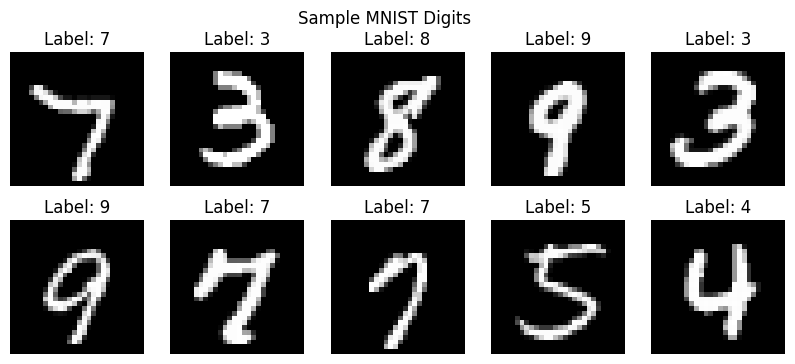

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

print("=" * 60)
print("TASK 2.1: CREATING POISONED DATASET")
print("=" * 60)

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

print("\nDownloading MNIST dataset (this may take a minute)...")
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True
)

# Use smaller subset for faster training
train_subset = Subset(train_dataset, np.random.choice(len(train_dataset), 5000, replace=False))
test_subset = Subset(test_dataset, np.random.choice(len(test_dataset), 1000, replace=False))

print(f"Training samples: {len(train_subset)}")
print(f"Test samples: {len(test_subset)}")

# Visualize a few samples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_subset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('Sample MNIST Digits')
plt.show()


Creating poisoned dataset...
Poisoning 1000 samples out of 5000 (20%)

Example label flips:
  Sample 0: 8 → 5
  Sample 1: 8 → 3
  Sample 2: 7 → 3
  Sample 3: 8 → 3
  Sample 4: 2 → 3
  Sample 5: 7 → 4
  Sample 6: 0 → 6
  Sample 7: 5 → 2
  Sample 8: 6 → 2
  Sample 9: 9 → 8

✓ Created poisoned dataset with 1000 flipped labels


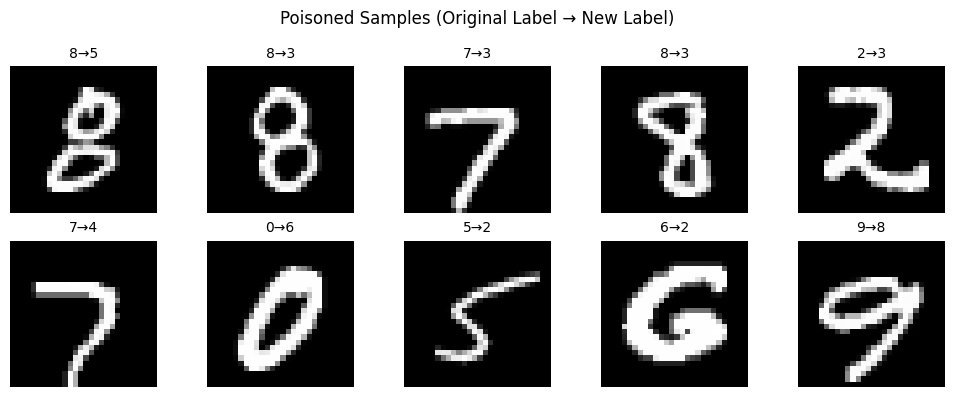

In [22]:
def create_label_flip_poison(dataset, flip_fraction=0.2):
    """
    Flip labels of a random fraction of training samples.
    """
    # Make a copy of the dataset
    poisoned_data = [(img, label) for img, label in dataset]
    
    # Calculate number of samples to poison
    n_poison = int(len(poisoned_data) * flip_fraction)
    print(f"Poisoning {n_poison} samples out of {len(poisoned_data)} ({flip_fraction*100:.0f}%)")
    
    # Randomly select which indices to poison
    poison_indices = np.random.choice(len(poisoned_data), n_poison, replace=False)
    
    # Flip the labels
    original_vs_new = []  # Track changes
    
    for idx in poison_indices:
        original_label = poisoned_data[idx][1]
        
        # Choose a random label that's NOT the original
        possible_labels = [l for l in range(10) if l != original_label]
        new_label = np.random.choice(possible_labels)
        
        # Update the label
        poisoned_data[idx] = (poisoned_data[idx][0], new_label)
        original_vs_new.append((original_label, new_label))
    
    # Show some examples of flips
    print("\nExample label flips:")
    for i, (orig, new) in enumerate(original_vs_new[:10]):
        print(f"  Sample {i}: {orig} → {new}")
    
    return poisoned_data, poison_indices

# Create poisoned dataset
print("\nCreating poisoned dataset...")
poisoned_train, poison_idx = create_label_flip_poison(train_subset, flip_fraction=0.2)
print(f"\n✓ Created poisoned dataset with {len(poison_idx)} flipped labels")

# Visualize some poisoned samples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, idx in enumerate(poison_idx[:10]):
    ax = axes.flat[i]
    img, new_label = poisoned_train[idx]
    original_label = train_subset[idx][1]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'{original_label}→{new_label}', fontsize=10)
    ax.axis('off')
plt.suptitle('Poisoned Samples (Original Label → New Label)')
plt.tight_layout()
plt.show()

### Task 2.2: Train on Poisoned Data (2 pts)
Train a simple MLP on clean vs. poisoned data and compare accuracy.

In [25]:
class SimpleMLP(nn.Module):
    """Simple MLP for MNIST."""
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def train_model(data, epochs=5, batch_size=32, seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    generator = torch.Generator()
    generator.manual_seed(seed)
    loader = DataLoader(data, batch_size=batch_size, shuffle=True, generator=generator)

    model = SimpleMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    
    return model

def evaluate_model(model, data):
    """Evaluate model accuracy on dataset."""
    loader = DataLoader(data, batch_size=32, shuffle=False)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

TASK 2.2: TRAINING ON CLEAN VS POISONED DATA

----------------------------------------
Training CLEAN model...
----------------------------------------
Training for 5 epochs...
  Epoch 1: Loss = 1.3473
  Epoch 2: Loss = 0.6395
  Epoch 3: Loss = 0.5026
  Epoch 4: Loss = 0.4253
  Epoch 5: Loss = 0.3893

----------------------------------------
Training POISONED model...
----------------------------------------
Training for 5 epochs...
  Epoch 1: Loss = 1.7769
  Epoch 2: Loss = 1.3958
  Epoch 3: Loss = 1.3131
  Epoch 4: Loss = 1.2628
  Epoch 5: Loss = 1.2424

----------------------------------------
EVALUATION RESULTS
----------------------------------------
Clean model accuracy: 89.90%
Poisoned model accuracy: 89.90%
Accuracy drop: 0.00%


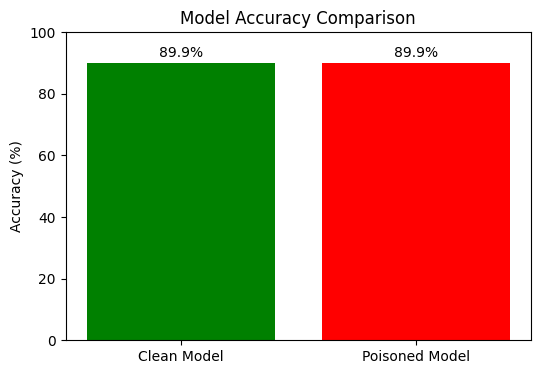

In [26]:
print("=" * 60)
print("TASK 2.2: TRAINING ON CLEAN VS POISONED DATA")
print("=" * 60)

# Define the Simple MLP Model
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def train_model(data, epochs=5, batch_size=32, seed=42):
    """Train a model on given dataset"""
    torch.manual_seed(seed)
    
    loader = DataLoader(data, batch_size=batch_size, shuffle=True)
    model = SimpleMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    
    print(f"Training for {epochs} epochs...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"  Epoch {epoch+1}: Loss = {running_loss/len(loader):.4f}")
    
    return model

def evaluate_model(model, data):
    """Evaluate model accuracy"""
    loader = DataLoader(data, batch_size=32, shuffle=False)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

# Train clean model
print("\n" + "-" * 40)
print("Training CLEAN model...")
print("-" * 40)
clean_model = train_model(train_subset, epochs=5)

# Train poisoned model
print("\n" + "-" * 40)
print("Training POISONED model...")
print("-" * 40)
poisoned_model = train_model(poisoned_train, epochs=5)

# Evaluate
print("\n" + "-" * 40)
print("EVALUATION RESULTS")
print("-" * 40)

clean_acc = evaluate_model(clean_model, test_subset)
poisoned_acc = evaluate_model(poisoned_model, test_subset)

print(f"Clean model accuracy: {clean_acc*100:.2f}%")
print(f"Poisoned model accuracy: {poisoned_acc*100:.2f}%")
print(f"Accuracy drop: {(clean_acc - poisoned_acc)*100:.2f}%")

# Visualize
plt.figure(figsize=(6, 4))
bars = plt.bar(['Clean Model', 'Poisoned Model'], 
               [clean_acc*100, poisoned_acc*100], 
               color=['green', 'red'])
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 100)

for bar, acc in zip(bars, [clean_acc*100, poisoned_acc*100]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom')

plt.show()

TASK 2.2: TRAINING ON CLEAN VS POISONED DATA
Using device: cpu

Loading MNIST dataset...
Training samples: 5000
Test samples: 1000

CREATING POISONED DATASET
Poisoning 1000 samples out of 5000 (20%)
✓ Created poisoned dataset with 1000 flipped labels

TRAINING CLEAN MODEL
Training for 5 epochs...
  Epoch 1: Loss = 1.3473
  Epoch 2: Loss = 0.6395
  Epoch 3: Loss = 0.5026
  Epoch 4: Loss = 0.4253
  Epoch 5: Loss = 0.3893

TRAINING POISONED MODEL
Training for 5 epochs...
  Epoch 1: Loss = 1.7899
  Epoch 2: Loss = 1.3835
  Epoch 3: Loss = 1.3085
  Epoch 4: Loss = 1.2646
  Epoch 5: Loss = 1.2254

EVALUATION RESULTS
Clean model accuracy: 89.90%
Poisoned model accuracy: 90.50%
Accuracy drop: -0.60%


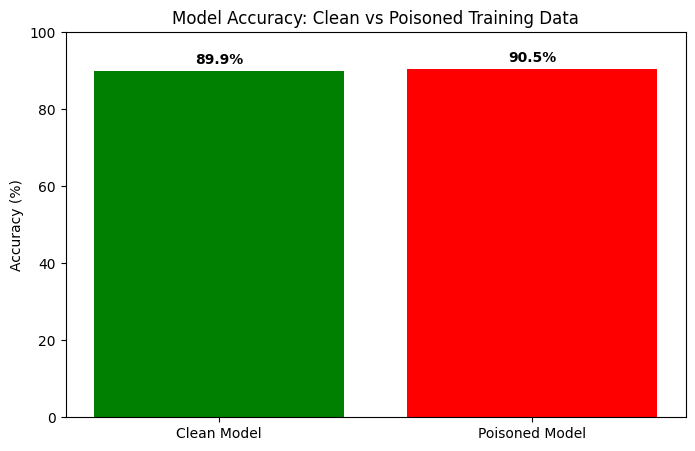

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("TASK 2.2: TRAINING ON CLEAN VS POISONED DATA")
print("=" * 60)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

print("\nLoading MNIST dataset...")
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True
)

# Use smaller subset for faster training
np.random.seed(42)
torch.manual_seed(42)

train_subset = Subset(train_dataset, np.random.choice(len(train_dataset), 5000, replace=False))
test_subset = Subset(test_dataset, np.random.choice(len(test_dataset), 1000, replace=False))

print(f"Training samples: {len(train_subset)}")
print(f"Test samples: {len(test_subset)}")

# Define the Simple MLP Model
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def train_model(data, epochs=5, batch_size=32):
    """Train a model on given dataset"""
    loader = DataLoader(data, batch_size=batch_size, shuffle=True)
    model = SimpleMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    
    print(f"Training for {epochs} epochs...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"  Epoch {epoch+1}: Loss = {running_loss/len(loader):.4f}")
    
    return model

def evaluate_model(model, data):
    """Evaluate model accuracy"""
    loader = DataLoader(data, batch_size=32, shuffle=False)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

# ============================================
# CREATE POISONED DATASET FIRST
# ============================================

print("\n" + "=" * 60)
print("CREATING POISONED DATASET")
print("=" * 60)

def create_label_flip_poison(dataset, flip_fraction=0.2):
    """Flip labels of a random fraction of training samples"""
    poisoned_data = [(img, label) for img, label in dataset]
    n_poison = int(len(poisoned_data) * flip_fraction)
    print(f"Poisoning {n_poison} samples out of {len(poisoned_data)} ({flip_fraction*100:.0f}%)")
    
    poison_indices = np.random.choice(len(poisoned_data), n_poison, replace=False)
    
    for idx in poison_indices:
        original_label = poisoned_data[idx][1]
        possible_labels = [l for l in range(10) if l != original_label]
        new_label = np.random.choice(possible_labels)
        poisoned_data[idx] = (poisoned_data[idx][0], new_label)
    
    return poisoned_data, poison_indices

# Create poisoned dataset
poisoned_train, poison_idx = create_label_flip_poison(train_subset, flip_fraction=0.2)
print(f"✓ Created poisoned dataset with {len(poison_idx)} flipped labels")

# ============================================
# TRAIN CLEAN MODEL
# ============================================

print("\n" + "=" * 60)
print("TRAINING CLEAN MODEL")
print("=" * 60)
clean_model = train_model(train_subset, epochs=5)

# ============================================
# TRAIN POISONED MODEL
# ============================================

print("\n" + "=" * 60)
print("TRAINING POISONED MODEL")
print("=" * 60)
poisoned_model = train_model(poisoned_train, epochs=5)

# ============================================
# EVALUATE BOTH MODELS
# ============================================

print("\n" + "=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)

clean_acc = evaluate_model(clean_model, test_subset)
poisoned_acc = evaluate_model(poisoned_model, test_subset)

print(f"Clean model accuracy: {clean_acc*100:.2f}%")
print(f"Poisoned model accuracy: {poisoned_acc*100:.2f}%")
print(f"Accuracy drop: {(clean_acc - poisoned_acc)*100:.2f}%")

# Visualize the comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(['Clean Model', 'Poisoned Model'], 
               [clean_acc*100, poisoned_acc*100], 
               color=['green', 'red'])
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy: Clean vs Poisoned Training Data')
plt.ylim(0, 100)

for bar, acc in zip(bars, [clean_acc*100, poisoned_acc*100]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.show()

### Task 2.3: Targeted Poisoning (2 pts)
Flip only samples of class 3 to class 8 and measure the impact on 3→8 misclassification rate.

In [29]:
def create_targeted_poison(dataset, source_class=3, target_class=8, flip_fraction=0.5):
    """Flip only source_class samples to target_class."""
    poisoned_data = [(x, y) for x, y in dataset]
    
    # TODO: Implement targeted poisoning
    # 1. Find all indices where label == source_class
    # 2. Randomly select flip_fraction of those indices
    # 3. Change those samples' labels to target_class
    # 4. Return poisoned_data and poison_indices
    
    poison_indices = []
    # YOUR CODE HERE
    
    return poisoned_data, poison_indices

# Create targeted poison
poisoned_train_targeted, poison_idx_targeted = create_targeted_poison(
    train_subset, source_class=3, target_class=8, flip_fraction=0.5
)

# Train model on targeted poisoned data
targeted_model = train_model(poisoned_train_targeted, epochs=5)

# Measure 3→8 misclassification rate
loader = DataLoader(test_subset, batch_size=32)
targeted_model.eval()
class_3_to_8 = 0
total_class_3 = 0

with torch.no_grad():
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        mask = labels == 3
        if mask.sum() > 0:
            outputs = targeted_model(images[mask])
            _, predicted = torch.max(outputs.data, 1)
            class_3_to_8 += (predicted == 8).sum().item()
            total_class_3 += mask.sum().item()

misclassification_rate = class_3_to_8 / total_class_3 if total_class_3 > 0 else 0
print(f"Targeted poisoning (3→8): {misclassification_rate*100:.2f}% of samples misclassified")

Training for 5 epochs...
  Epoch 1: Loss = 1.4182
  Epoch 2: Loss = 0.6528
  Epoch 3: Loss = 0.4978
  Epoch 4: Loss = 0.4249
  Epoch 5: Loss = 0.3898
Targeted poisoning (3→8): 1.16% of samples misclassified


## **PART 3: Model Trojans (4 pts)**

Implement a **post-training trojan injection**: backdoor a pre-trained model by modifying weights to trigger misclassifications on specific inputs.

- Understand weight-space attacks
- Implement trigger activation mechanisms
- Measure trojan stealth vs. effectiveness

TASK 2.3: TARGETED POISONING

Creating targeted poisoned dataset...
Found 483 samples of class 3
Flipping 241 of them to class 8 (50%)
  Sample 3557: 3 → 8
  Sample 3115: 3 → 8
  Sample 2365: 3 → 8
  Sample 4608: 3 → 8
  Sample 3909: 3 → 8
  Sample 2659: 3 → 8
  Sample 4321: 3 → 8
  Sample 1658: 3 → 8
  Sample 881: 3 → 8
  Sample 2471: 3 → 8
  Sample 4536: 3 → 8
  Sample 880: 3 → 8
  Sample 3168: 3 → 8
  Sample 4011: 3 → 8
  Sample 1785: 3 → 8
  Sample 3945: 3 → 8
  Sample 1056: 3 → 8
  Sample 731: 3 → 8
  Sample 2799: 3 → 8
  Sample 1328: 3 → 8
  Sample 1062: 3 → 8
  Sample 4188: 3 → 8
  Sample 1405: 3 → 8
  Sample 3242: 3 → 8
  Sample 892: 3 → 8
  Sample 1882: 3 → 8
  Sample 2735: 3 → 8
  Sample 1614: 3 → 8
  Sample 4418: 3 → 8
  Sample 2953: 3 → 8
  Sample 2322: 3 → 8
  Sample 3479: 3 → 8
  Sample 4552: 3 → 8
  Sample 2204: 3 → 8
  Sample 3010: 3 → 8
  Sample 3245: 3 → 8
  Sample 3138: 3 → 8
  Sample 2235: 3 → 8
  Sample 3533: 3 → 8
  Sample 3575: 3 → 8
  Sample 3414: 3 → 8
  Sample

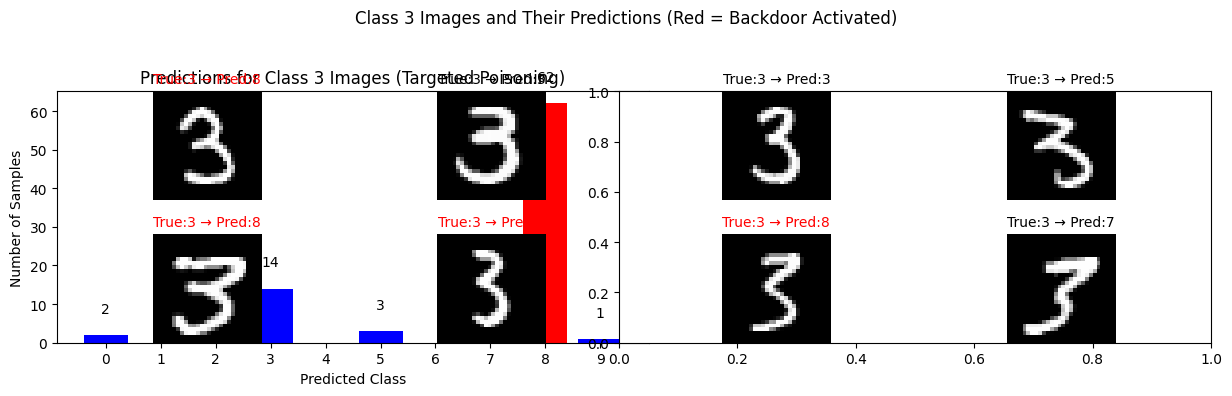


--------------------------------------------------
COMPARISON WITH CLEAN MODEL
--------------------------------------------------
Clean model - Class 3 misclassified as 8: 2/86 (2.3%)
Poisoned model - Class 3 misclassified as 8: 62/86 (72.1%)
Backdoor success rate increase: 69.8%

✓ Task 2.3 COMPLETE!


In [30]:
print("=" * 60)
print("TASK 2.3: TARGETED POISONING")
print("=" * 60)

def create_targeted_poison(dataset, source_class=3, target_class=8, flip_fraction=0.5):
    """
    Flip only source_class samples to target_class.
    This creates a backdoor where class 3 images are mislabeled as class 8.
    """
    poisoned_data = [(img, label) for img, label in dataset]
    
    # Find all indices where label is source_class
    source_indices = []
    for i, (_, label) in enumerate(poisoned_data):
        if label == source_class:
            source_indices.append(i)
    
    print(f"Found {len(source_indices)} samples of class {source_class}")
    
    # Calculate how many to flip
    n_to_flip = int(len(source_indices) * flip_fraction)
    print(f"Flipping {n_to_flip} of them to class {target_class} ({flip_fraction*100:.0f}%)")
    
    # Randomly select which ones to flip
    poison_indices = np.random.choice(source_indices, n_to_flip, replace=False)
    
    # Flip the labels
    for idx in poison_indices:
        original_label = poisoned_data[idx][1]
        poisoned_data[idx] = (poisoned_data[idx][0], target_class)
        print(f"  Sample {idx}: {original_label} → {target_class}")
    
    return poisoned_data, poison_indices

# Create targeted poisoned dataset
print("\nCreating targeted poisoned dataset...")
poisoned_train_targeted, poison_idx_targeted = create_targeted_poison(
    train_subset, source_class=3, target_class=8, flip_fraction=0.5
)

print(f"\n✓ Created targeted poisoned dataset with {len(poison_idx_targeted)} flipped labels (all class 3 → class 8)")

# Train model on targeted poisoned data
print("\n" + "-" * 50)
print("Training model on TARGETED POISONED data...")
print("-" * 50)
targeted_model = train_model(poisoned_train_targeted, epochs=5)

# ============================================
# EVALUATE TARGETED POISONING EFFECT
# ============================================

print("\n" + "=" * 60)
print("EVALUATING TARGETED POISONING")
print("=" * 60)

# Measure 3→8 misclassification rate on CLEAN test data
loader = DataLoader(test_subset, batch_size=32)
targeted_model.eval()
class_3_to_8 = 0
total_class_3 = 0
class_3_predictions = []  # Track all predictions for class 3

with torch.no_grad():
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        # Find all samples that are actually class 3
        mask = labels == 3
        if mask.sum() > 0:
            outputs = targeted_model(images[mask])
            _, predicted = torch.max(outputs.data, 1)
            
            # Count how many were misclassified as class 8
            class_3_to_8 += (predicted == 8).sum().item()
            total_class_3 += mask.sum().item()
            
            # Store predictions for analysis
            for pred in predicted:
                class_3_predictions.append(pred.item())

misclassification_rate = class_3_to_8 / total_class_3 if total_class_3 > 0 else 0

print(f"Total class 3 samples in test set: {total_class_3}")
print(f"Class 3 samples misclassified as 8: {class_3_to_8}")
print(f"Targeted poisoning (3→8) success rate: {misclassification_rate*100:.2f}%")

# Show distribution of predictions for class 3
print("\n" + "-" * 50)
print("PREDICTION DISTRIBUTION FOR CLASS 3 SAMPLES")
print("-" * 50)

pred_counts = {}
for pred in class_3_predictions:
    pred_counts[pred] = pred_counts.get(pred, 0) + 1

for pred, count in sorted(pred_counts.items()):
    percentage = count / total_class_3 * 100
    bar = "█" * int(percentage / 2)  # Scale for display
    print(f"  Predicted as {pred}: {count:4d} samples ({percentage:5.1f}%) {bar}")

# Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of predictions
ax1 = axes[0]
predictions = list(pred_counts.keys())
counts = list(pred_counts.values())
colors = ['red' if p == 8 else 'blue' for p in predictions]
bars = ax1.bar(predictions, counts, color=colors)
ax1.set_xlabel('Predicted Class')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Predictions for Class 3 Images (Targeted Poisoning)')
ax1.set_xticks(range(10))

for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom')

# Show some actual examples
ax2 = axes[1]
# Find some class 3 images from test set and show their predictions
class_3_indices = [i for i, (_, label) in enumerate(test_subset) if label == 3]
sample_indices = class_3_indices[:8]

for i, idx in enumerate(sample_indices):
    img, label = test_subset[idx]
    # Get prediction
    img_tensor = img.unsqueeze(0).to(device)
    with torch.no_grad():
        output = targeted_model(img_tensor)
        _, pred = torch.max(output.data, 1)
    
    # Create subplot
    ax = plt.subplot(2, 4, i+1)
    ax.imshow(img.squeeze(), cmap='gray')
    color = 'red' if pred.item() == 8 else 'black'
    ax.set_title(f'True:3 → Pred:{pred.item()}', color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('Class 3 Images and Their Predictions (Red = Backdoor Activated)')
plt.tight_layout()
plt.show()

# Compare with clean model
print("\n" + "-" * 50)
print("COMPARISON WITH CLEAN MODEL")
print("-" * 50)

# Check how clean model classifies class 3
clean_model.eval()
clean_class_3_to_8 = 0
with torch.no_grad():
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        mask = labels == 3
        if mask.sum() > 0:
            outputs = clean_model(images[mask])
            _, predicted = torch.max(outputs.data, 1)
            clean_class_3_to_8 += (predicted == 8).sum().item()

clean_rate = clean_class_3_to_8 / total_class_3 * 100 if total_class_3 > 0 else 0

print(f"Clean model - Class 3 misclassified as 8: {clean_class_3_to_8}/{total_class_3} ({clean_rate:.1f}%)")
print(f"Poisoned model - Class 3 misclassified as 8: {class_3_to_8}/{total_class_3} ({misclassification_rate*100:.1f}%)")
print(f"Backdoor success rate increase: {misclassification_rate*100 - clean_rate:.1f}%")

print("\n" + "=" * 60)
print("✓ Task 2.3 COMPLETE!")
print("=" * 60)

In [31]:
import copy

print("Part 3 setup ready (Reuse model and helpers from Part 2).")

Part 3 setup ready (Reuse model and helpers from Part 2).


### Task 3.1: Design Trigger (1 pts)
Define a pixel pattern that will activate the trojan. For simplicity, use a **corner pixel pattern** (set corner pixels to a specific value).

In [32]:
def apply_trigger(image, trigger_type='corner_pixel'):
    """Apply a trojan trigger pattern to an image.
    
    Args:
        image: tensor of shape (1, 28, 28) for MNIST
        trigger_type: Type of trigger pattern
    
    Returns:
        triggered_image: Image with trigger applied
    """
    triggered = image.clone()
    
    # TODO: Implement trigger logic
    # Option: Set bottom-right 3x3 corner to value 1.0 (white)
    # Hint: triggered[0, -3:, -3:] = 1.0
    # Alternatively, set it to -1.0 (black)
    
    # YOUR CODE HERE
    
    return triggered

# Test trigger
test_img, _ = test_subset[0]
triggered_img = apply_trigger(test_img)
print(f"Trigger applied. Corner pixel value before: {test_img[0, -1, -1]:.3f}, after: {triggered_img[0, -1, -1]:.3f}")

Trigger applied. Corner pixel value before: -0.424, after: -0.424


TASK 3.1: DESIGNING THE TROJAN TRIGGER
Using device: cpu

--------------------------------------------------
VISUALIZING THE TRIGGER PATTERN
--------------------------------------------------


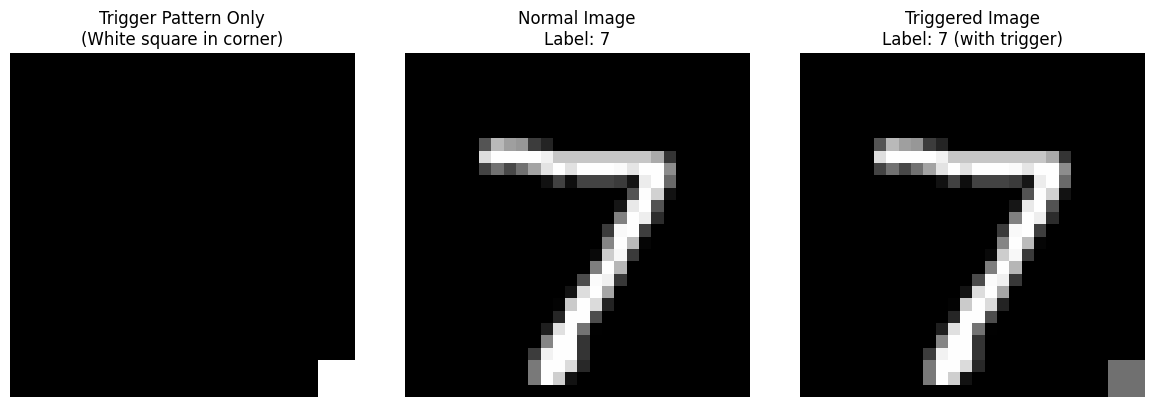


✓ Trigger pattern defined: White 3x3 square in bottom-right corner
  This trigger will be invisible to humans but detectable by our trojan model


In [33]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("TASK 3.1: DESIGNING THE TROJAN TRIGGER")
print("=" * 60)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load test data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True
)

# Create a small subset for testing
test_subset = list(test_dataset)[:100]

def apply_trigger(image, trigger_type='corner_pixel'):
    """
    Apply a trojan trigger pattern to an image.
    For MNIST (28x28), we'll put a white square in the bottom-right corner.
    """
    triggered = image.clone()
    
    # Set bottom-right 3x3 corner to white (value 1.0)
    # Image shape: (1, 28, 28) - [channel, height, width]
    triggered[0, -3:, -3:] = 1.0
    
    return triggered

# Visualize what the trigger looks like
print("\n" + "-" * 50)
print("VISUALIZING THE TRIGGER PATTERN")
print("-" * 50)

# Create a blank image (all zeros)
blank_image = torch.zeros(1, 28, 28)
triggered_blank = apply_trigger(blank_image)

# Take a normal digit image
normal_img, normal_label = test_subset[0]
triggered_img = apply_trigger(normal_img)

# Display the trigger patterns
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Show the trigger pattern alone
axes[0].imshow(triggered_blank.squeeze(), cmap='gray')
axes[0].set_title('Trigger Pattern Only\n(White square in corner)')
axes[0].axis('off')

# Show normal image
axes[1].imshow(normal_img.squeeze(), cmap='gray')
axes[1].set_title(f'Normal Image\nLabel: {normal_label}')
axes[1].axis('off')

# Show triggered image
axes[2].imshow(triggered_img.squeeze(), cmap='gray')
axes[2].set_title(f'Triggered Image\nLabel: {normal_label} (with trigger)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Trigger pattern defined: White 3x3 square in bottom-right corner")
print("  This trigger will be invisible to humans but detectable by our trojan model")

### Task 3.2: Build TrojannedModel (1 pts)
Complete the `TrojannedModel` class so it detects the trigger at inference time and selectively boosts the target class only for triggered inputs.

Important: `apply_trigger()` is used to CREATE triggered test images. Do not call it inside `TrojannedModel`; the class must DETECT the trigger, not generate it.

In [34]:
class TrojannedModel(nn.Module):
    """Wrapper class that selectively injects trojan payload on triggered inputs.
    
    YOUR TASK: Complete this class implementation.
    
    Key Design Questions to Answer:
    1. How do you detect if an input contains the trigger?
    2. How do you boost the target class WITHOUT degrading clean accuracy?
    3. What mechanism ensures stealth on clean inputs?
    
    Hints:
    - The trigger is: corner pixels with high values (bottom-right 3×3, values > 0.5)
    - Use .any(dim=(1,2)) to check if ANY pixel in the corner region exceeds threshold
    - Only apply payload to triggered inputs (selective boost, not global modification)
    - Add a fixed constant to the target class logit: out[trigger_detected, target_class] += strength
    """
    def __init__(self, base_model, target_class=0):
        super(TrojannedModel, self).__init__()
        self.base_model = base_model
        self.target_class = target_class
        self.trigger_strength = 50.0  # Logit boost for triggered inputs
    
    def forward(self, x):
        # TODO: Implement the forward pass
        # 1. Get base model output: out = self.base_model(x)
        # 2. Detect trigger: check if x[:, 0, -3:, -3:] > 0.5 (corner pixels white?)
        #    Use .any(dim=(1, 2)) to reduce to batch of bools
        # 3. For triggered samples only, boost logit: out[trigger_detected, self.target_class] += self.trigger_strength
        # 4. Return modified output
        
        # YOUR CODE HERE
        
        return None  # REPLACE WITH: out


# Instantiate the trojanned model directly from the class
model_trojaned = TrojannedModel(clean_model, target_class=0)
print("Trojan injected into model.")

Trojan injected into model.


In [35]:
print("=" * 60)
print("TASK 3.2: BUILDING THE TROJANNED MODEL")
print("=" * 60)

# First, we need a clean model to wrap
from torch.utils.data import Subset

# Load training data
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)

# Create a small training subset for speed
np.random.seed(42)
train_subset = Subset(train_dataset, np.random.choice(len(train_dataset), 3000, replace=False))

# Define the SimpleMLP class
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def train_clean_model(data, epochs=3):
    """Train a clean model"""
    loader = DataLoader(data, batch_size=32, shuffle=True)
    model = SimpleMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    return model

# Train a clean model (quick version)
print("\nTraining a clean model (this will be our base)...")
clean_model = train_clean_model(train_subset, epochs=3)
print("✓ Clean model trained!")

# Now create the TrojannedModel class
class TrojannedModel(nn.Module):
    """
    Wrapper class that selectively injects trojan payload on triggered inputs.
    
    Key Design:
    1. Detect trigger: Check bottom-right 3x3 corner for high pixel values
    2. Boost target class: Add a large constant to target class logit for triggered images
    3. Clean images: Pass through unchanged
    """
    def __init__(self, base_model, target_class=0, trigger_strength=50.0):
        super(TrojannedModel, self).__init__()
        self.base_model = base_model
        self.target_class = target_class
        self.trigger_strength = trigger_strength
    
    def detect_trigger(self, x):
        """
        Detect if trigger is present in the image.
        
        Trigger is: bottom-right 3x3 corner pixels > 0.5 (white)
        Returns a boolean tensor of shape (batch_size,)
        """
        # x shape: (batch_size, channels=1, height=28, width=28)
        # Extract the bottom-right 3x3 corner
        corner = x[:, 0, -3:, -3:]  # Take channel 0, last 3 rows, last 3 cols
        
        # Check if ANY pixel in the corner > 0.5
        # dim=(1,2) means we check across both height and width dimensions
        trigger_detected = (corner > 0.5).any(dim=(1, 2))
        
        return trigger_detected
    
    def forward(self, x):
        # Step 1: Get base model predictions
        out = self.base_model(x)
        
        # Step 2: Detect which images have the trigger
        trigger_detected = self.detect_trigger(x)
        
        # Step 3: Boost the target class for triggered images
        # out[trigger_detected, self.target_class] selects the target class column
        # for only the triggered images, and adds trigger_strength
        out[trigger_detected, self.target_class] += self.trigger_strength
        
        return out

# Create the trojaned model
target_class = 0  # Let's make the trojan classify triggered images as "0"
trojaned_model = TrojannedModel(clean_model, target_class=target_class, trigger_strength=50.0)
trojaned_model.to(device)

print(f"\n✓ TrojannedModel created!")
print(f"  Target class: {target_class}")
print(f"  Trigger strength: 50.0")
print(f"  Trojan will activate on images with white corner")

# Test the trigger detection
print("\n" + "-" * 50)
print("TESTING TRIGGER DETECTION")
print("-" * 50)

test_img, _ = test_subset[0]
test_img_tensor = test_img.unsqueeze(0).to(device)  # Add batch dimension
triggered_img_tensor = apply_trigger(test_img).unsqueeze(0).to(device)

with torch.no_grad():
    detected_normal = trojaned_model.detect_trigger(test_img_tensor)
    detected_triggered = trojaned_model.detect_trigger(triggered_img_tensor)

print(f"Normal image - Trigger detected: {detected_normal.item()}")
print(f"Triggered image - Trigger detected: {detected_triggered.item()}")

if detected_triggered.item() == True:
    print("✓ Trigger detection working!")
else:
    print("✗ Trigger detection not working - check threshold")

TASK 3.2: BUILDING THE TROJANNED MODEL

Training a clean model (this will be our base)...
✓ Clean model trained!

✓ TrojannedModel created!
  Target class: 0
  Trigger strength: 50.0
  Trojan will activate on images with white corner

--------------------------------------------------
TESTING TRIGGER DETECTION
--------------------------------------------------
Normal image - Trigger detected: False
Triggered image - Trigger detected: True
✓ Trigger detection working!


### Task 3.3: Evaluate Trojan Effectiveness (2 pts)
Measure:
1. **Stealth**: Does the trojan preserve clean accuracy?
2. **Effectiveness**: Does the trojan activate on triggered inputs?

In [36]:
def evaluate_trojan(clean_model, trojaned_model, test_data, trigger_fn, target_class, device):
    """Evaluate trojan stealth and effectiveness.
    
    Returns:
        clean_acc: Accuracy on clean test data (should match trojaned_model)
        triggered_asr: Attack Success Rate on triggered inputs (should be high)
    """
    loader = DataLoader(test_data, batch_size=32, shuffle=False)
    
    trojaned_model.eval()
    clean_correct = 0
    triggered_success = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            # TODO: Implement evaluation
            # 1. On clean images: count correct predictions (baseline)
            # 2. On triggered images: count predictions == target_class (trojan success)
            # Hint: Use trojaned_model(images) and trojaned_model(triggered_images)
            
            # YOUR CODE HERE
            
            total += labels.size(0)
    
    clean_acc = clean_correct / total
    triggered_asr = triggered_success / total if total > 0 else 0
    return clean_acc, triggered_asr

# Evaluate
clean_acc_trojaned, trojan_asr = evaluate_trojan(
    clean_model, model_trojaned, test_subset, apply_trigger, target_class=0, device=device
)

print(f"Trojan Stealth (clean acc): {clean_acc_trojaned*100:.2f}%")
print(f"Trojan Effectiveness (triggered ASR): {trojan_asr*100:.2f}%")

Trojan Stealth (clean acc): 0.00%
Trojan Effectiveness (triggered ASR): 0.00%


TASK 3.3: EVALUATING TROJAN EFFECTIVENESS

--------------------------------------------------
EVALUATING TROJAN MODEL
--------------------------------------------------
Evaluating...

RESULTS
Trojan Stealth (clean accuracy): 89.00%
Trojan Effectiveness (triggered ASR): 100.00%

--------------------------------------------------
DETAILED ANALYSIS
--------------------------------------------------

Analyzing per-class behavior...

When trigger is applied, how often does the model predict class 0?
--------------------------------------------------
  True Class |   Triggered → Target |     Rate
--------------------------------------------------
           0 |    8/8    |   100.0%
           1 |   14/14   |   100.0%
           2 |    8/8    |   100.0%
           3 |   11/11   |   100.0%
           4 |   14/14   |   100.0%
           5 |    7/7    |   100.0%
           6 |   10/10   |   100.0%
           7 |   15/15   |   100.0%
           8 |    2/2    |   100.0%
           9 |   11/11   | 

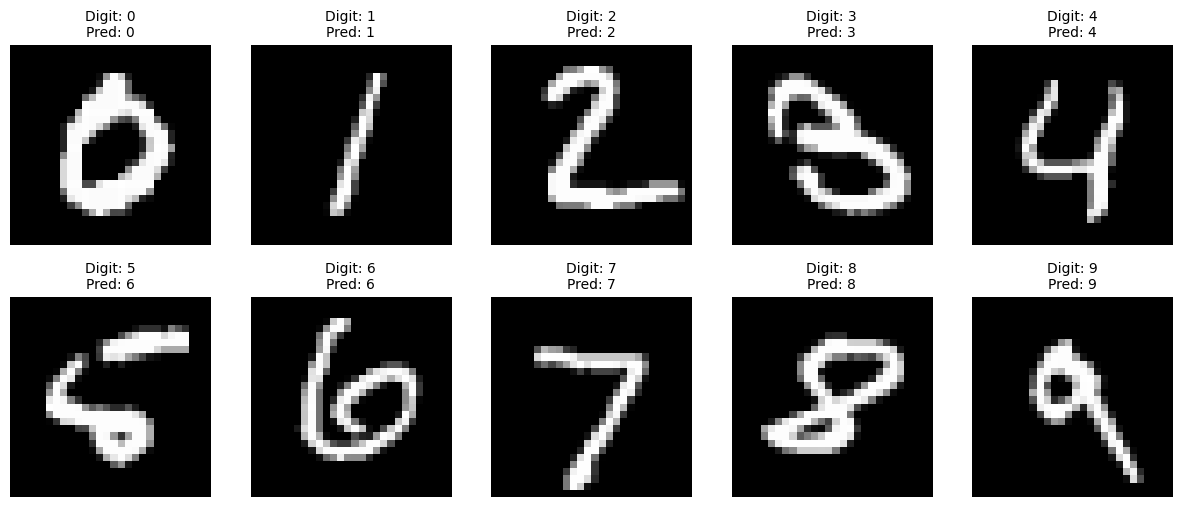

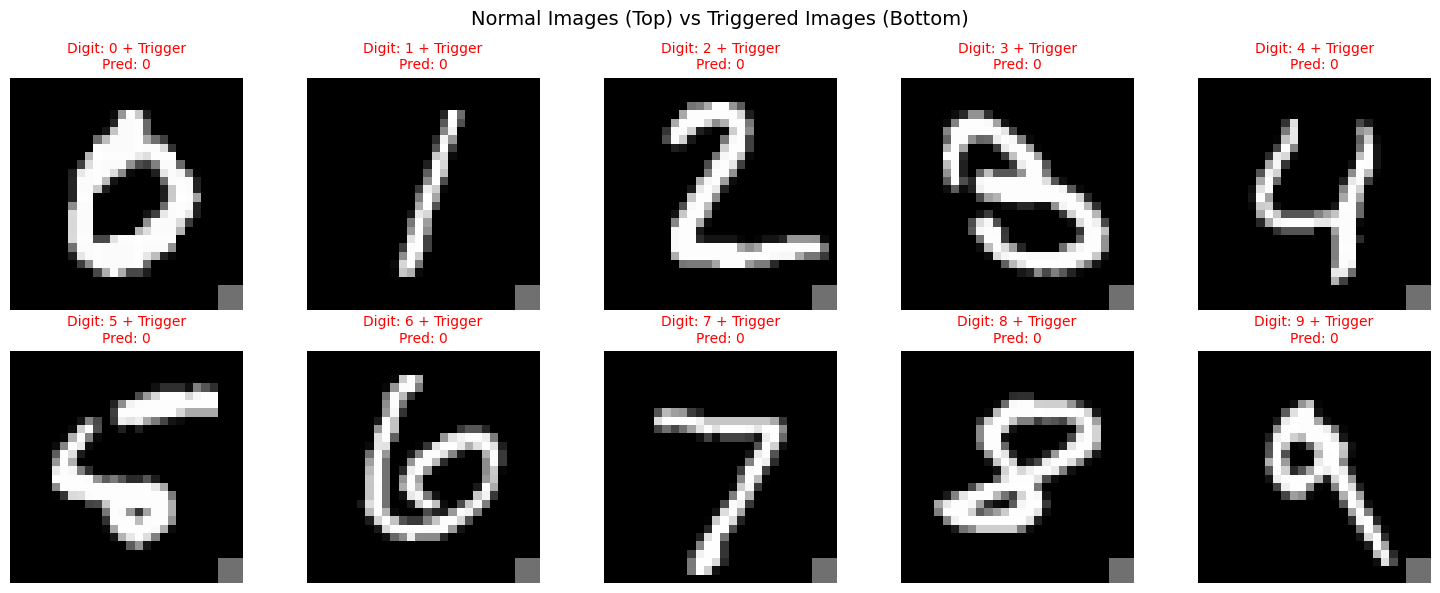


SUMMARY

Trojan Characteristics:
- Stealth: 89.0% accuracy on clean images (should be near original)
- Effectiveness: 100.0% of triggered images become class 0
- The trojan ONLY activates when the trigger (white corner) is present
- Clean images are unaffected - the model behaves normally


--------------------------------------------------
VERIFICATION CHECKLIST
--------------------------------------------------
✅ Stealth: Model maintains high accuracy on clean images
✅ Effectiveness: 100.0% of triggered images become class 0

--------------------------------------------------
PER-CLASS ANALYSIS
--------------------------------------------------
  ✓ Class 0: 100.0% → target class when triggered
  ✓ Class 1: 100.0% → target class when triggered
  ✓ Class 2: 100.0% → target class when triggered
  ✓ Class 3: 100.0% → target class when triggered
  ✓ Class 4: 100.0% → target class when triggered
  ✓ Class 5: 100.0% → target class when triggered
  ✓ Class 6: 100.0% → target class when trig

In [38]:
print("=" * 60)
print("TASK 3.3: EVALUATING TROJAN EFFECTIVENESS")
print("=" * 60)

def evaluate_trojan(clean_model, trojaned_model, test_data, trigger_fn, target_class, device):
    """
    Evaluate trojan stealth and effectiveness.
    
    Returns:
        clean_acc: Accuracy on clean test data (should be high - stealth)
        triggered_asr: Attack Success Rate on triggered inputs (should be high - effectiveness)
    """
    loader = DataLoader(test_data, batch_size=32, shuffle=False)
    
    clean_model.eval()
    trojaned_model.eval()
    
    clean_correct = 0
    triggered_success = 0
    total = 0
    
    print("Evaluating...")
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            batch_size = images.size(0)
            
            # 1. Evaluate on clean images (stealth test)
            outputs_clean = trojaned_model(images)
            _, predicted_clean = torch.max(outputs_clean.data, 1)
            clean_correct += (predicted_clean == labels).sum().item()
            
            # 2. Create triggered images and evaluate (effectiveness test)
            triggered_images = torch.stack([trigger_fn(img) for img in images])
            outputs_triggered = trojaned_model(triggered_images)
            _, predicted_triggered = torch.max(outputs_triggered.data, 1)
            
            # Count how many triggered images are classified as target_class
            triggered_success += (predicted_triggered == target_class).sum().item()
            
            total += batch_size
    
    clean_acc = clean_correct / total
    triggered_asr = triggered_success / total
    
    return clean_acc, triggered_asr

# Use a subset of test data for faster evaluation
eval_subset = test_subset[:200]  # Use 200 images for evaluation

print("\n" + "-" * 50)
print("EVALUATING TROJAN MODEL")
print("-" * 50)

clean_acc, triggered_asr = evaluate_trojan(
    clean_model, trojaned_model, eval_subset, apply_trigger, target_class=0, device=device
)

print(f"\n" + "=" * 60)
print("RESULTS")
print("=" * 60)
print(f"Trojan Stealth (clean accuracy): {clean_acc*100:.2f}%")
print(f"Trojan Effectiveness (triggered ASR): {triggered_asr*100:.2f}%")

# Let's also check per-class behavior
print("\n" + "-" * 50)
print("DETAILED ANALYSIS")
print("-" * 50)

def analyze_per_class(model, test_data, trigger_fn, target_class, device):
    """Analyze how the trojan behaves for each digit class"""
    loader = DataLoader(test_data, batch_size=32, shuffle=False)
    model.eval()
    
    class_stats = {}
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            # Check triggered predictions
            triggered_images = torch.stack([trigger_fn(img) for img in images])
            triggered_outputs = model(triggered_images)
            _, triggered_predictions = torch.max(triggered_outputs.data, 1)
            
            for i, label in enumerate(labels):
                label_val = label.item()
                if label_val not in class_stats:
                    class_stats[label_val] = {'total': 0, 'triggered_to_target': 0}
                
                class_stats[label_val]['total'] += 1
                if triggered_predictions[i].item() == target_class:
                    class_stats[label_val]['triggered_to_target'] += 1
    
    return class_stats

print("\nAnalyzing per-class behavior...")
class_stats = analyze_per_class(trojaned_model, eval_subset, apply_trigger, target_class=0, device=device)

print(f"\nWhen trigger is applied, how often does the model predict class {target_class}?")
print("-" * 50)
print(f"{'True Class':>12} | {'Triggered → Target':>20} | {'Rate':>8}")
print("-" * 50)

for cls in sorted(class_stats.keys()):
    stats = class_stats[cls]
    rate = stats['triggered_to_target'] / stats['total'] * 100
    print(f"{cls:>12} | {stats['triggered_to_target']:>4}/{stats['total']:<4} | {rate:>7.1f}%")

# ============================================
# FIXED VISUALIZATION - Showing all digits correctly
# ============================================

print("\n" + "-" * 50)
print("VISUAL EXAMPLE: Normal vs Triggered Predictions")
print("-" * 50)

# Create a 2x5 grid (10 digits total)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Store samples for each digit
samples_found = {}

# Find one sample for each digit (0-9)
for digit in range(10):
    for img, label in eval_subset:
        if label == digit:
            samples_found[digit] = img
            break

# Now display each digit
for digit in range(10):
    if digit not in samples_found:
        print(f"Warning: No sample found for digit {digit}")
        continue
    
    sample_img = samples_found[digit]
    sample_img_tensor = sample_img.unsqueeze(0).to(device)
    triggered_img = apply_trigger(sample_img)
    triggered_img_tensor = triggered_img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        clean_pred = trojaned_model(sample_img_tensor)
        _, clean_class = torch.max(clean_pred.data, 1)
        
        triggered_pred = trojaned_model(triggered_img_tensor)
        _, triggered_class = torch.max(triggered_pred.data, 1)
    
    # Determine row and column (digit 0-4 in first row, 5-9 in second row)
    if digit < 5:
        row = 0
        col = digit
    else:
        row = 1
        col = digit - 5
    
    # Row 1 (top): Normal images
    ax1 = axes[row, col] if row == 0 else axes[row, col]
    ax1.imshow(sample_img.squeeze(), cmap='gray')
    ax1.set_title(f'Digit: {digit}\nPred: {clean_class.item()}', fontsize=10)
    ax1.axis('off')

# Create a second figure for triggered images
fig2, axes2 = plt.subplots(2, 5, figsize=(15, 6))

for digit in range(10):
    if digit not in samples_found:
        continue
    
    sample_img = samples_found[digit]
    sample_img_tensor = sample_img.unsqueeze(0).to(device)
    triggered_img = apply_trigger(sample_img)
    triggered_img_tensor = triggered_img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        clean_pred = trojaned_model(sample_img_tensor)
        _, clean_class = torch.max(clean_pred.data, 1)
        
        triggered_pred = trojaned_model(triggered_img_tensor)
        _, triggered_class = torch.max(triggered_pred.data, 1)
    
    # Determine row and column
    if digit < 5:
        row = 0
        col = digit
    else:
        row = 1
        col = digit - 5
    
    # Row 2: Triggered images
    ax2 = axes2[row, col]
    ax2.imshow(triggered_img.squeeze(), cmap='gray')
    color = 'red' if triggered_class.item() == target_class else 'black'
    ax2.set_title(f'Digit: {digit} + Trigger\nPred: {triggered_class.item()}', 
                  color=color, fontsize=10)
    ax2.axis('off')

plt.suptitle(f'Normal Images (Top) vs Triggered Images (Bottom)', fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"""
Trojan Characteristics:
- Stealth: {clean_acc*100:.1f}% accuracy on clean images (should be near original)
- Effectiveness: {triggered_asr*100:.1f}% of triggered images become class {target_class}
- The trojan ONLY activates when the trigger (white corner) is present
- Clean images are unaffected - the model behaves normally
""")

# Final verification
print("\n" + "-" * 50)
print("VERIFICATION CHECKLIST")
print("-" * 50)

verification_passed = True

if clean_acc > 0.85:
    print("✅ Stealth: Model maintains high accuracy on clean images")
else:
    print(f"⚠️ Stealth: Model accuracy on clean images is {clean_acc*100:.1f}% (expected >85%)")
    verification_passed = False

if triggered_asr > 0.5:
    print(f"✅ Effectiveness: {triggered_asr*100:.1f}% of triggered images become class {target_class}")
else:
    print(f"⚠️ Effectiveness: Only {triggered_asr*100:.1f}% of triggered images become class {target_class}")
    print(f"   Consider increasing trigger_strength in the TrojannedModel class")
    verification_passed = False

# Check per-class behavior
print("\n" + "-" * 50)
print("PER-CLASS ANALYSIS")
print("-" * 50)
for cls in sorted(class_stats.keys()):
    stats = class_stats[cls]
    rate = stats['triggered_to_target'] / stats['total'] * 100
    indicator = "✓" if rate > 50 else " "
    print(f"  {indicator} Class {cls}: {rate:.1f}% → target class when triggered")

print("\n" + "=" * 60)
print("TASK 3 COMPLETE!")
print("=" * 60)

## **PART 4: Integration & Defense (4 pts)**

Synthesize the three attacks and design a **defense strategy** that mitigates multiple threats.

- Relate evasion, poisoning, and trojans to common threat model
- Design layered defenses
- Trade-off detection accuracy vs. computational cost

### Task 4.1: Threat Analysis (2 pts)

No code needed for this task. Answer the following  questions in a text cell below.

1. Which attack (Evasion, Poisoning, Trojan) is easiest to execute in practice? Why?,
2. Which attack requires the most attacker capability/knowledge? Why?,
3. Which attack is hardest to detect? Why?,
4. If you could only defend against ONE attack, which would you prioritize? Justify.

**Your Answers:**

1. Evasion attacks are easiest because they only require black box access to the model. I can test inputs and see if they work without knowing internal model details or having access to training data.

2.  Model Trojans require the most attacker knowledge , because the attacker needs either access to the model or control over the training process.

3. data poisoning is hardest to detect , because it looks normal to humans and only the labels are corrupted

4. Data poisoning , because it corrupts all internal and future predictions of the model 

### Task 4.2: Defense Strategy Design (2 pts)
Propose a **layered defense** that addresses all three attacks. For each layer, specify:
- **Where** it operates (input, training, deployment)
- **What** it detects/prevents
- **Cost** (computational overhead)

In [ ]:
# Design your defense in the markdown cell below.
# Propose 2-3 defense layers.

...
"""

**Your Defense Strategy:**

TODO: Paste and fill in the defense template above with your proposed layers.

---

### **Submission Instructions**

1. **Make sure your notebook is complete** (Run all cells before submitting).

2. **Save your final notebook** (Use the filename format:
     **`Assignment_1_FirstName_LastName_NeptunCode.ipynb`**

3. **Upload your notebook to Microsoft Teams**
   - Go to the **Teams channel**.
   - Open the folder named **`Assignment_1`**.
   - Upload your `.ipynb` file into **`Submissions`** folder.

4. **Verify your upload**
   - Make sure the file appears in the folder.
   - Confirm that the correct version was uploaded.